# FEM Pendulum: Impact Event Detection

In [10]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from demos.ControlledPendulum.src.master_pendulum.components import FEMPendulum  
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import System
from syssimx.system.connection import EventConnection

In [11]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

---------------------

In [ ]:
model = FEMPendulum(name="FEM_Pendulum", group="Plant")

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.3)  # Initial angle

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = True
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

model.set_parameters(
    init_params=init_params,
    sim_params=sim_params,
)

model.initialize(0.0)

# Add event indicator for wall contact
def wall_contact_event_indicator(model: FEMPendulum) -> float:
    return model.get_outputs()["theta"].magnitude


model.add_event_indicator(
    name="wall_hit", func=wall_contact_event_indicator, direction=-1
)

system = System(name="FEM_Pendulum_System")
system.add_component(model)

event_connection = EventConnection(
    src_comp=model.name,
    src_port=model.output_specs["wall_hit"].name,
    dst_comp=model.name,
    dst_port=model.input_specs["omega_invert"].name,
)
system.add_event_connection(event_connection)
system.initialize(0.0)

In [13]:
system.algorithm.record_internal_steps = False
system.algorithm.event_dedup_tol = 5e-4
system.algorithm.tol_time = 1e-5
system.algorithm.tol_value = 5e-5

In [14]:
# 6) Run simulation with event detection
t_start = 0.0
t_end = sim_params.t_end
dt = sim_params.tau

system.run(t0=t_start, tf=t_end, dt=dt)

[system] INFO: Starting simulation run from t=0.0 to t=1 with dt=0.01
[hybrid] DEBUG: Internal hint: FEM_Pendulum.wall_hit in [0.23900000, 0.23910000]
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.230000, 0.240000]: FEM_Pendulum.wall_hit
[hybrid] DEBUG:   Internal hints from FEM_Pendulum: ['wall_hit']
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Narrowed interval via hint: [0.230000, 0.240000] -> [0.239000, 0.239100]
[hybrid] DEBUG: Indicators at left  (t=0.23900000): {'FEM_Pendulum': {'wall_hit': 0.00016315014960227152}}
[hybrid] DEBUG: Indicators at right (t=0.23910000): {'FEM_Pendulum': {'wall_hit': -3.3849664522976916e-05}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.23900000, 0.23910000]
[hybrid] DEBUG: Bisection iteration 2: interval [0.23905000, 0.23910000]
[hybrid] DEBUG: Bisection iteration 3: interval [0.23907500, 0.23910000]
[hybrid] DEBUG: Indicator 

[FEM_Pendulum] Event 'wall_hit' at t=0.2391s.


[hybrid] DEBUG: Internal hint: FEM_Pendulum.wall_hit in [0.71650000, 0.71660000]
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.710000, 0.720000]: FEM_Pendulum.wall_hit
[hybrid] DEBUG:   Internal hints from FEM_Pendulum: ['wall_hit']
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Narrowed interval via hint: [0.710000, 0.720000] -> [0.716500, 0.716600]
[hybrid] DEBUG: Indicators at left  (t=0.71650000): {'FEM_Pendulum': {'wall_hit': 0.00015189610262131558}}
[hybrid] DEBUG: Indicators at right (t=0.71660000): {'FEM_Pendulum': {'wall_hit': -4.664505204896208e-05}}
[hybrid] DEBUG: Bisection iteration 1: interval [0.71650000, 0.71660000]
[hybrid] DEBUG: Bisection iteration 2: interval [0.71655000, 0.71660000]
[hybrid] DEBUG: Bisection iteration 3: interval [0.71657500, 0.71660000]
[hybrid] DEBUG: Indicator FEM_Pendulum.wall_hit = -4.6645e-05
[hybrid] INFO: Event located at t=0

[FEM_Pendulum] Event 'wall_hit' at t=0.7166s.


[system] INFO: Simulation completed in 321.24 seconds


In [7]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history["FEM_Pendulum"]
event_history = history["Events"]

t_vals, data = pendulum_history
q_vals = data["theta"]
omega_vals = data["omega"]
alpha_vals = data["alpha"]

# Get event times
event_times = event_history.get(("FEM_Pendulum", "wall_hit"), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 1 events
First event at t = 0.23908750 s


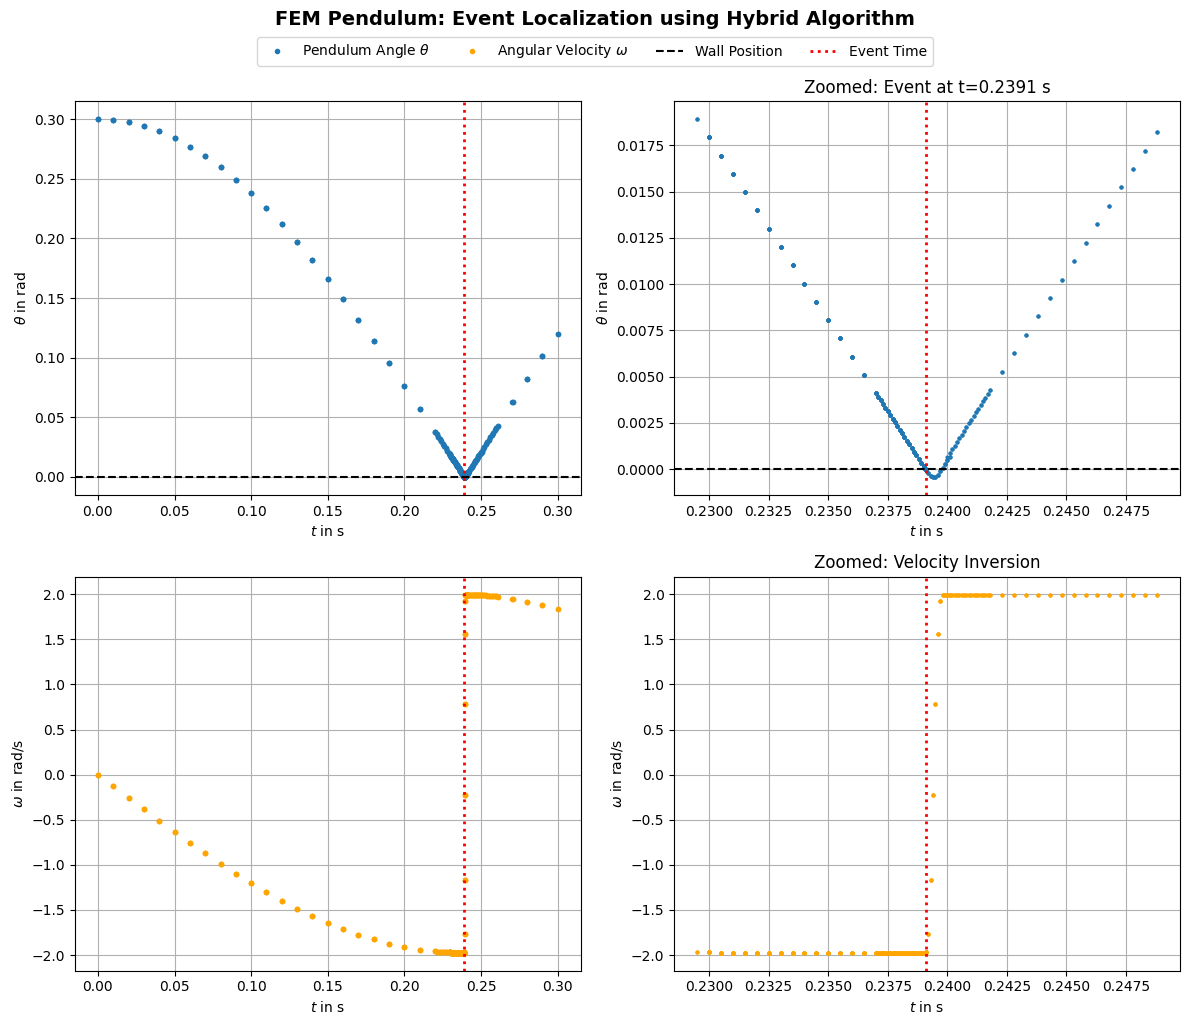

In [8]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "FEM Pendulum: Event Localization using Hybrid Algorithm",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

# Top left: Full angle trajectory
(line1,) = axs[0, 0].plot(
    t_vals, q_vals, label=r"Pendulum Angle $\theta$", marker="o", markersize=3, linestyle="None"
)
line2 = axs[0, 0].axhline(0, color="k", linestyle="--", label="Wall Position")
if t_event:
    line3 = axs[0, 0].axvline(
        t_event.t, color="red", linestyle=":", linewidth=2, label="Event Time"
    )
axs[0, 0].set_xlabel(r"$t$ in $\mathrm{s}$")
axs[0, 0].set_ylabel(r"$\theta$ in $\mathrm{rad}$")
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.01
    mask = (t_vals >= t_event.t - zoom_window) & (t_vals <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals[mask], q_vals[mask], "o", markersize=2)
    axs[0, 1].axhline(0, color="k", linestyle="--")
    axs[0, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[0, 1].set_xlabel(r"$t$ in $\mathrm{s}$")
    axs[0, 1].set_ylabel(r"$\theta$ in $\mathrm{rad}$")
    axs[0, 1].set_title(f"Zoomed: Event at t={t_event.t:.4f} s")
    axs[0, 1].grid()

# Bottom left: Full angular velocity
(line4,) = axs[1, 0].plot(
    t_vals, omega_vals, "o",color="orange", label=r"Angular Velocity $\omega$", markersize=3
)

if t_event:
    axs[1, 0].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
axs[1, 0].set_xlabel(r"$t$ in $\mathrm{s}$")
axs[1, 0].set_ylabel(r"$\omega$ in $\mathrm{rad/s}$")
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals[mask], omega_vals[mask], "o", color="orange", markersize=2)
    axs[1, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[1, 1].set_xlabel(r"$t$ in $\mathrm{s}$")
    axs[1, 1].set_ylabel(r"$\omega$ in $\mathrm{rad/s}$")
    axs[1, 1].set_title("Zoomed: Velocity Inversion")
    axs[1, 1].grid()

signals = [line1, line4, line2, line3]  # , line5]
labels = [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc="upper center", bbox_to_anchor=(0.5, 1), ncol=5)

plt.tight_layout()
plt.show()